In [63]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [64]:
path = "../data/export_-JO-O--An-lise-Full_2025-12-16_16-57-32.csv"
df_safras = pd.read_csv(path)

df_safras.columns = [c.strip() for c in df_safras.columns]

print(df_safras.shape)
df_safras.head(5)

(4961, 141)


,[OTIMA] is_subscriber?,[PAGO] Data do Pagamento,[PAGO] Valor Emprestado,[PH3A] Lista de telefones HOT,[PH3A] Telefone HOT é o da Proposta?,[PH3A] Tem telefone HOT?,[SRM] Codigo OP,[SRM] VTM,Análise de Crédito Backtest,Análise de Crédito Original,Backtest ID,CALC - # Assistances Subprime,CALC - % Assistances Subprime,CALC - Assistances Ativas,CALC - Carteira Vencida SCR / Renda Anual,CALC - Créditos a Liberar / VTM,CALC - Endividamento Filme SCR / Endividamento SCR,CALC - Valor em Assistances Ativas,CALC - Valor em Assistances Subprime,Classe de Risco b2e,Clinica,Consulta scr erro?,consulta srm filme erro?,CPF Proposta,Data Analise/Proposta,dataVencimento 1a Parcela,DT|Payment 1,DT|Payment 2,DT|Payment 3,DT|Payment 4,DT|Payment 5,DT|Payment 6,Estado Empregatício Informado,Filme - Consulta,Filme SCR - % Dividas Prime 31 a 90,Filme SCR - % Dividas Prime Total,Filme SCR - % Dividas Subprime 31 a 90,Filme SCR - % Dividas Subprime Total,Filme SCR - A Vencer Ate 30d,Filme SCR - A Vencer Ate 31d-60d,Filme SCR - A Vencer Ate 61d-90d,Filme SCR - Carteira de Crédito,Filme SCR - Creditos a Liberar,Filme SCR - Qtd Insituições,Filme SCR - Qtd. Operações,Filme SCR - Tempo de Relacionamento (anos),Filme SCR - Total Prejuízo,Filme SCR - Total Vencido,Filme SCR - Valor Médio Desembolso (31-90),Idade Cliente,Lista de defaults,Lista de triggers,Mesa de Crédito,Parcela 1,Parcela 2,Parcela 3,Parcela 4,Parcela 5,Parcela 6,PH3A - # de Ocupações,PH3A - Consulta,PH3A - Credit Score D00,PH3A - Credit Score D30,PH3A - Credit Score D60,PH3A - Credit Score D90,PH3A - Empregado?,PH3A - Lista de Assistances,PH3A - Lista de LawProcesses,PH3A - Lista de Professions,PH3A - Lista de StatisticalModels,PH3A - Pre Screening D00,PH3A - Pre Screening D30,PH3A - Pre Screening D60,PH3A - Pre Screening D90,PH3A - Renda Familiar,PH3A - Renda Presumida,PH3A - Tempo em Ocupações,PH3A - Tempo Médio Ocupações,PH3A - Tempo Ocupação Atual,PH3A S.M - Perfil de Aposta Online,PH3A S.M - Perfil de Comportamento Digital,PH3A S.M - Perfil de Consorcio,PH3A S.M - Perfil de Consumo de Luxo,PH3A S.M - Perfil de Conta Bancária de Investimento,PH3A S.M - Perfil de Conta Bancária Digital,PH3A S.M - Perfil de Conta Bancária Premium,PH3A S.M - Perfil de Pontos e Milhas,PH3A S.M - Perfil de Posse de Automóvel,PH3A S.M - Perfil de Posse de Imóvel,PH3A S.M - Perfil de Pós-Graduação,PH3A S.M - Perfil de Seguro,PH3A S.M - Perfil de Tomador de Empréstimos,PH3A S.M - Perfil de Veículo Zero KM,PH3A S.M - Perfil Entusiasta de Tecnologia,PH3A S.M - Perfil Posse de Moto,Política,Política Rebate,proposal,Realizar Ligação WC?,Risco Cadastral,Risco Clinica - Number,Score Serasa,SCR - % Dividas Prime 31 a 90,SCR - % Dividas Prime Total,SCR - % Dividas Subprime 31 a 90,SCR - % Dividas Subprime Total,SCR - A Vencer Ate 30d,SCR - A Vencer Ate 31d-60d,SCR - A Vencer Ate 61d-90d,SCR - Carteira de Crédito,SCR - Consulta,SCR - Creditos a Liberar,SCR - Fornecedor,SCR - Limite de Credito Acima360,SCR - Limite de Credito Ate360,SCR - Modalidades,SCR - Qtd Insituições,SCR - Qtd. Operações,SCR - Tempo de Relacionamento (anos),SCR - Total Prejuízo,SCR - Total Vencido,SCR - Valor Médio Desembolso (31-90),Serasa - # Pefins,Serasa - # Protestos,Serasa - # Refins,Serasa - # Restrições,Serasa - Ações Judiciais,Serasa - Consulta,Serasa - Valor Pefins,Serasa - Valor Protestos,Serasa - Valor Refins,Serasa - Valor Restrições,Taxa de Juros,Taxa de Juros Rebate,Telefone da Proposta,Versão da Análise,Creation Date,Modified Date,Slug,Creator,unique id
0,NaN,"May 8, 2024 3:30 pm",2240,61999010918,não,sim,1108159.0,"3431,96902396",1763763074584x543876027040007600,1715115436205x242653755560831460,1765546069921x610147793410457600,1,1,1,NaN,0,0,400,400,NaN,PM11257 - ODONTO VIDA,NaN,não,4578150194,NaN,"Jun 15, 2024 5:59 pm",1715290224735x962043060594012400,1715290229044x217291625160436860,1715290234107x850571593791377400,1715290239078x562020359788988800,1715290244102x941875175813320200,1715290249101x273821374819849020,EMPREGADO CLT,174

In [66]:
MONTH_MAP_PT_EN = {
    r"(?i)\bjan\.?\b": "Jan", r"(?i)\bfev\.?\b": "Feb", r"(?i)\bmar\.?\b": "Mar",
    r"(?i)\babr\.?\b": "Apr", r"(?i)\bmai\.?\b": "May", r"(?i)\bjun\.?\b": "Jun",
    r"(?i)\bjul\.?\b": "Jul", r"(?i)\bago\.?\b": "Aug", r"(?i)\bset\.?\b": "Sep",
    r"(?i)\bout\.?\b": "Oct", r"(?i)\bnov\.?\b": "Nov", r"(?i)\bdez\.?\b": "Dec",
}

def parse_mixed_datetime_fast(col: pd.Series) -> pd.Series:
    # Se já é datetime, não mexe
    if pd.api.types.is_datetime64_any_dtype(col):
        return col

    # 1) tenta converter números (serial do Excel/Sheets)
    num = pd.to_numeric(col, errors="coerce")
    dt_num = pd.to_datetime(num, unit="D", origin="1899-12-30", errors="coerce")

    # 2) normaliza texto
    txt = col.astype("string").str.strip()
    txt = txt.replace(MONTH_MAP_PT_EN, regex=True)
    txt = txt.str.replace(r"\.(?=\s*\d)", "", regex=True)  # "jun. 5" -> "Jun 5"
    txt = txt.str.replace(r"\s+", " ", regex=True)

    # máscaras por padrão
    m_ampm = txt.str.contains(r"\b(am|pm)\b", case=False, na=False)
    m_time = txt.str.contains(r"\d{1,2}:\d{2}", na=False) & ~m_ampm
    m_comma = txt.str.contains(",", na=False) & ~(m_ampm | m_time)

    # 3) parse por formato explícito (sem warning)
    dt_ampm = pd.to_datetime(txt.where(m_ampm), format="%b %d, %Y %I:%M %p", errors="coerce")
    dt_24h  = pd.to_datetime(txt.where(m_time), format="%b %d, %Y %H:%M", errors="coerce")
    dt_date = pd.to_datetime(txt.where(m_comma), format="%b %d, %Y", errors="coerce")

    # 4) fallback (pequeno resto). Usa format="mixed" (Pandas 2+) para evitar inferência ruidosa
    rest_mask = ~(m_ampm | m_time | m_comma)
    dt_rest = pd.to_datetime(txt.where(rest_mask), format="mixed", dayfirst=True, errors="coerce")

    # combina
    out = dt_num
    out = out.fillna(dt_ampm).fillna(dt_24h).fillna(dt_date).fillna(dt_rest)
    return out

def to_float_br(s: pd.Series) -> pd.Series:
    s = s.astype("string").str.strip()
    s = s.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
    # remove separador de milhar quando existir e troca vírgula por ponto
    s = s.str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
    return pd.to_numeric(s, errors="coerce")

def to_pct_br(s: pd.Series) -> pd.Series:
    s = s.astype("string").str.strip().str.replace("%", "", regex=False)
    return to_float_br(s) / 100

def to_bool_sim_nao(s: pd.Series) -> pd.Series:
    s = s.astype("string").str.strip().str.lower()
    return s.isin(["sim", "s", "true", "1", "yes"])


In [67]:
date_cols = [
    "Creation Date",
    "Modified Date",
    "Data Analise/Proposta",
    "[PAGO] Data do Pagamento",
    "dataVencimento 1a Parcela",
]

for c in date_cols:
    if c in df_safras.columns:
        df_safras[c] = parse_mixed_datetime_fast(df_safras[c])
        print(f"{c}: NaT% = {df_safras[c].isna().mean():.2%}")


Creation Date: NaT% = 0.00%
Modified Date: NaT% = 0.00%
Data Analise/Proposta: NaT% = 56.50%
[PAGO] Data do Pagamento: NaT% = 0.12%
dataVencimento 1a Parcela: NaT% = 0.00%


In [68]:
num_cols = [
    "[PAGO] Valor Emprestado",
    "Idade Cliente",
    "Score Serasa",
    "Taxa de Juros",
    "Taxa de Juros Rebate",
    "PH3A - Renda Familiar",
    "PH3A - Renda Presumida",
    "PH3A - Pre Screening D00",
    "SCR - Total Vencido",
    "SCR - Total Prejuízo",
    "SCR - Valor Médio Desembolso (31-90)",
    "SCR - Qtd. Operações",
    "SCR - Qtd Insituições",
]
for c in num_cols:
    if c in df_safras.columns:
        df_safras[c] = to_float_br(df_safras[c])

In [71]:
bool_cols = [
    "[OTIMA] is_subscriber?",
    "[PH3A] Tem telefone HOT?",
    "[PH3A] Telefone HOT é o da Proposta?",
    "Consulta scr erro?",
    "consulta srm filme erro?",
    "Realizar Ligação WC?",
]
for c in bool_cols:
    if c in df_safras.columns:
        df_safras[c] = to_bool_sim_nao(df_safras[c])

In [72]:
df_safras["Safras_Mes"] = df_safras["Data Analise/Proposta"].dt.to_period("M").astype(str)

In [73]:
df_safras["Pago_Flag"] = df_safras["[PAGO] Data do Pagamento"].notna()| (df_safras["[PAGO] Valor Emprestado"].fillna(0) > 0)

In [79]:
df_safras["incidente_consulta"] = df_safras.get("Consulta scr erro?", False).fillna(False) | df_safras.get("consulta srm filme erro?", False).fillna(False)
df_safras["incidente_tel_hot"] = df_safras.get("[PH3A] Tem telefone HOT?", False).fillna(False)
df_safras["incidente_wc"] = df_safras.get("Realizar Ligação WC?", False).fillna(False)

# “incidente geral” (você pode ajustar pesos depois)
df_safras["incidente_flag"] = df_safras["incidente_consulta"] | df_safras["incidente_tel_hot"] | df_safras["incidente_wc"]

In [81]:
df_safras["rebate_flag"] = df_safras["Política Rebate"].notna() | (df_safras.get("Taxa de Juros Rebate", 0).fillna(0) != 0)

In [83]:
qa = pd.DataFrame({
    "col": ["unique id","proposal","Clinica","Política","Creation Date","[PAGO] Data do Pagamento","[PAGO] Valor Emprestado","Score Serasa","PH3A - Pre Screening D00"],
    "missing_%": [
        df_safras["unique id"].isna().mean() if "unique id" in df_safras.columns else np.nan,
        df_safras["proposal"].isna().mean() if "proposal" in df_safras.columns else np.nan,
        df_safras["Clinica"].isna().mean() if "Clinica" in df_safras.columns else np.nan,
        df_safras["Política"].isna().mean() if "Política" in df_safras.columns else np.nan,
        df_safras["Creation Date"].isna().mean() if "Creation Date" in df_safras.columns else np.nan,
        df_safras["[PAGO] Data do Pagamento"].isna().mean() if "[PAGO] Data do Pagamento" in df_safras.columns else np.nan,
        df_safras["[PAGO] Valor Emprestado"].isna().mean() if "[PAGO] Valor Emprestado" in df_safras.columns else np.nan,
        df_safras["Score Serasa"].isna().mean() if "Score Serasa" in df_safras.columns else np.nan,
        df_safras["PH3A - Pre Screening D00"].isna().mean() if "PH3A - Pre Screening D00" in df_safras.columns else np.nan,
    ]
})
qa


,col,missing_%
0,unique id,0.000000
1,proposal,0.000000
2,Clinica,0.000000
3,Política,1.000000
4,Creation Date,0.000000
5,[PAGO] Data do Pagamento,0.001209
6,[PAGO] Valor Emprestado,0.000202
7,Score Serasa,0.003628
8,PH3A - Pre Screening D00,0.170933


In [85]:
if "unique id" in df_safras.columns:
    print("Duplicados unique id", df_safras["unique id"].duplicated().mean())

Duplicados unique id 0.0


In [87]:
df_safras.head(30)

,[OTIMA] is_subscriber?,[PAGO] Data do Pagamento,[PAGO] Valor Emprestado,[PH3A] Lista de telefones HOT,[PH3A] Telefone HOT é o da Proposta?,[PH3A] Tem telefone HOT?,[SRM] Codigo OP,[SRM] VTM,Análise de Crédito Backtest,Análise de Crédito Original,Backtest ID,CALC - # Assistances Subprime,CALC - % Assistances Subprime,CALC - Assistances Ativas,CALC - Carteira Vencida SCR / Renda Anual,CALC - Créditos a Liberar / VTM,CALC - Endividamento Filme SCR / Endividamento SCR,CALC - Valor em Assistances Ativas,CALC - Valor em Assistances Subprime,Classe de Risco b2e,Clinica,Consulta scr erro?,consulta srm filme erro?,CPF Proposta,Data Analise/Proposta,dataVencimento 1a Parcela,DT|Payment 1,DT|Payment 2,DT|Payment 3,DT|Payment 4,DT|Payment 5,DT|Payment 6,Estado Empregatício Informado,Filme - Consulta,Filme SCR - % Dividas Prime 31 a 90,Filme SCR - % Dividas Prime Total,Filme SCR - % Dividas Subprime 31 a 90,Filme SCR - % Dividas Subprime Total,Filme SCR - A Vencer Ate 30d,Filme SCR - A Vencer Ate 31d-60d,Filme SCR - A Vencer Ate 61d-90d,Filme SCR - Carteira de Crédito,Filme SCR - Creditos a Liberar,Filme SCR - Qtd Insituições,Filme SCR - Qtd. Operações,Filme SCR - Tempo de Relacionamento (anos),Filme SCR - Total Prejuízo,Filme SCR - Total Vencido,Filme SCR - Valor Médio Desembolso (31-90),Idade Cliente,Lista de defaults,Lista de triggers,Mesa de Crédito,Parcela 1,Parcela 2,Parcela 3,Parcela 4,Parcela 5,Parcela 6,PH3A - # de Ocupações,PH3A - Consulta,PH3A - Credit Score D00,PH3A - Credit Score D30,PH3A - Credit Score D60,PH3A - Credit Score D90,PH3A - Empregado?,PH3A - Lista de Assistances,PH3A - Lista de LawProcesses,PH3A - Lista de Professions,PH3A - Lista de StatisticalModels,PH3A - Pre Screening D00,PH3A - Pre Screening D30,PH3A - Pre Screening D60,PH3A - Pre Screening D90,PH3A - Renda Familiar,PH3A - Renda Presumida,PH3A - Tempo em Ocupações,PH3A - Tempo Médio Ocupações,PH3A - Tempo Ocupação Atual,PH3A S.M - Perfil de Aposta Online,PH3A S.M - Perfil de Comportamento Digital,PH3A S.M - Perfil de Consorcio,PH3A S.M - Perfil de Consumo de Luxo,PH3A S.M - Perfil de Conta Bancária de Investimento,PH3A S.M - Perfil de Conta Bancária Digital,PH3A S.M - Perfil de Conta Bancária Premium,PH3A S.M - Perfil de Pontos e Milhas,PH3A S.M - Perfil de Posse de Automóvel,PH3A S.M - Perfil de Posse de Imóvel,PH3A S.M - Perfil de Pós-Graduação,PH3A S.M - Perfil de Seguro,PH3A S.M - Perfil de Tomador de Empréstimos,PH3A S.M - Perfil de Veículo Zero KM,PH3A S.M - Perfil Entusiasta de Tecnologia,PH3A S.M - Perfil Posse de Moto,Política,Política Rebate,proposal,Realizar Ligação WC?,Risco Cadastral,Risco Clinica - Number,Score Serasa,SCR - % Dividas Prime 31 a 90,SCR - % Dividas Prime Total,SCR - % Dividas Subprime 31 a 90,SCR - % Dividas Subprime Total,SCR - A Vencer Ate 30d,SCR - A Vencer Ate 31d-60d,SCR - A Vencer Ate 61d-90d,SCR - Carteira de Crédito,SCR - Consulta,SCR - Creditos a Liberar,SCR - Fornecedor,SCR - Limite de Credito Acima360,SCR - Limite de Credito Ate360,SCR - Modalidades,SCR - Qtd Insituições,SCR - Qtd. Operações,SCR - Tempo de Relacionamento (anos),SCR - Total Prejuízo,SCR - Total Vencido,SCR - Valor Médio Desembolso (31-90),Serasa - # Pefins,Serasa - # Protestos,Serasa - # Refins,Serasa - # Restrições,Serasa - Ações Judiciais,Serasa - Consulta,Serasa - Valor Pefins,Serasa - Valor Protestos,Serasa - Valor Refins,Serasa - Valor Restrições,Taxa de Juros,Taxa de Juros Rebate,Telefone da Proposta,Versão da Análise,Creation Date,Modified Date,Slug,Creator,unique id,Safras_Mes,Pago_Flag,incidente_consulta,incidente_tel_hot,incidente_wc,incidente_flag,rebate_flag
0,False,2024-05-08 15:30:00,2240.0,61999010918,False,True,1108159.0,"3431,96902396",1763763074584x543876027040007600,1715115436205x242653755560831460,1765546069921x610147793410457600,1,1,1,NaN,0,0,400,400,NaN,PM11257 - ODONTO VIDA,False,False,4578150194,NaT,2024-06-15 17:59:00,1715290224735x962043060594012400,1715290229044x217291625160436860,1715290234107x850571593791377400,171529023907

In [89]:
df_safra_analise = df_safras.copy()

VAL = "[PAGO] Valor Emprestado"

df_safra_analise["Valor_Pago"] = np.where(df_safra_analise["Pago_Flag"], df_safra_analise[VAL].fillna(0), 0)

meses = ["2025-10", "2025-11", "2025-12"]
base = df_safra_analise[df_safra_analise["Safras_Mes"].isin(meses)].copy()

base["Política"] = base["Política"].astype("string").fillna("SEM_POLITICA")
base["Clinica"] = base["Clinica"].astype("string").fillna("SEM_CLINICA")
base["Estado Empregatício Informado"] = base["Estado Empregatício Informado"].astype("string").fillna("NAO_INFORMADO")

In [91]:
kpi_mes = (base.groupby("Safras_Mes", as_index=False)
    .agg(
        propostas=("unique id", "count"),
        pagos=("Pago_Flag", "sum"),
        conv_pago=("Pago_Flag", "mean"),
        total_pago=("Valor_Pago", "sum"),
        total_vencido=("SCR - Total Vencido", "sum"),
        ticket_medio_pago=("Valor_Pago", lambda s: s[s > 0].mean()),
        incidente_rate=("incidente_flag", "mean"),
        rebate_rate=("rebate_flag", "mean"),
        subscriber_rate=("[OTIMA] is_subscriber?", "mean")
            if "[OTIMA] is_subscriber?" in base.columns else ("Pago_Flag", "mean"),
    )
)

# métricas derivadas (depois do agg)
kpi_mes["tx_atraso_scr_sobre_pago"] = kpi_mes["total_vencido"] / kpi_mes["total_pago"].replace({0: np.nan})
kpi_mes["vencido_medio_por_pago"]   = kpi_mes["total_vencido"] / kpi_mes["pagos"].replace({0: np.nan})

kpi_mes


,Safras_Mes,propostas,pagos,conv_pago,total_pago,total_vencido,ticket_medio_pago,incidente_rate,rebate_rate,subscriber_rate,tx_atraso_scr_sobre_pago,vencido_medio_por_pago
0,2025-10,273,273,1.0,855801.506,3571.87,3134.804051,0.842491,0.0,0.776557,0.004174,13.083773
1,2025-11,208,208,1.0,672894.998,6203.8,3235.072106,0.850962,0.0,0.846154,0.00922,29.825962
2,2025-12,50,50,1.0,200067.525,847.16,4001.350500,0.960000,0.0,0.900000,0.004234,16.9432


In [93]:
kpi_emprego = (base.groupby(["Safras_Mes","Estado Empregatício Informado"], as_index=False)
                 .agg(
                     propostas=("unique id","count"),
                     conv_pago=("Pago_Flag","mean"),
                     total_pago=("Valor_Pago","sum"),
                     total_vencido=("SCR - Total Vencido", "sum"),
                     ticket_medio_pago=("Valor_Pago", lambda s: s[s>0].mean()),
                     score_serasa=("Score Serasa","mean") if "Score Serasa" in base.columns else ("Pago_Flag","mean"),
                 )
              ).sort_values(["Safras_Mes","propostas"], ascending=[True, False])

kpi_emprego.head(20)


,Safras_Mes,Estado Empregatício Informado,propostas,conv_pago,total_pago,total_vencido,ticket_medio_pago,score_serasa
1,2025-10,AUTÔNOMO,160,1.0,429123.110,19.22,2682.019438,8209.9375
4,2025-10,NAO_INFORMADO,99,1.0,360004.422,2829.35,3636.408303,7912.346939
3,2025-10,EMPREGADO CLT,6,1.0,23933.974,0.0,3988.995667,7956.666667
0,2025-10,APOSENTADO,4,1.0,26340.000,723.3,6585.000000,9220.0
2,2025-10,DESEMPREGADO / FUNC. PÚBLICO COMISSIONADO,2,1.0,7200.000,0.0,3600.000000,9725.0
5,2025-10,SÓCIO,2,1.0,9200.000,0.0,4600.000000,8755.0
7,2025-11,AUTÔNOMO,129,1.0,361338.810,4458.39,2801.076047,8018.992248
10,2025-11,NAO_INFORMADO,61,1.0,229426.188,936.8,3761.085049,8103.606557
9,2025-11,EMPREGADO CLT,12,1.0,61430.000,808.61,5119.166667,7917.5
6,2025-11,APOSENTADO,2,1.0,7080.000,0.0,3540.000000,7220.0


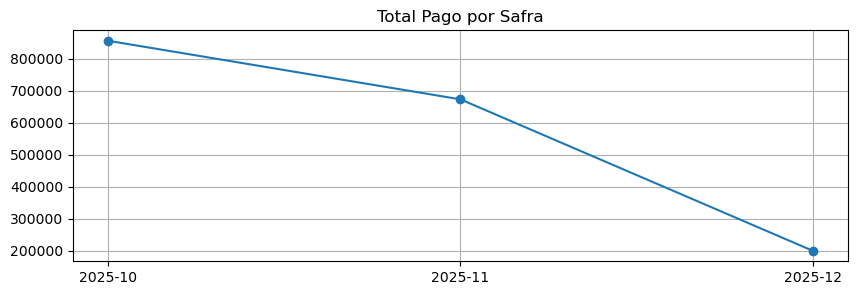

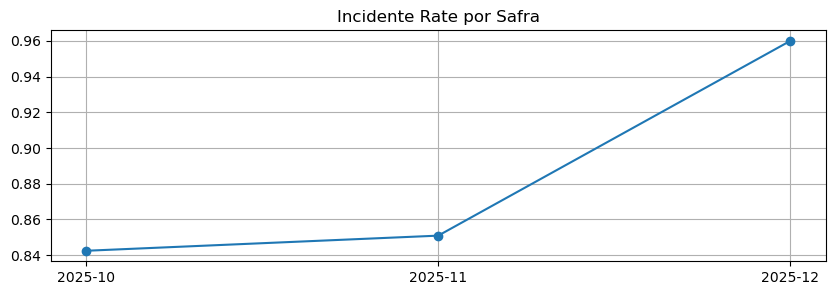

In [95]:
plt.figure(figsize=(10,3))
plt.plot(kpi_mes["Safras_Mes"], kpi_mes["total_pago"], marker="o")
plt.title("Total Pago por Safra")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,3))
plt.plot(kpi_mes["Safras_Mes"], kpi_mes["incidente_rate"], marker="o")
plt.title("Incidente Rate por Safra")
plt.grid(True)
plt.show()


In [96]:
top = (kpi_emprego.groupby("Estado Empregatício Informado")["propostas"]
          .sum()
          .sort_values(ascending=False)
          .head(5)
          .index)

emp_top = kpi_emprego[kpi_emprego["Estado Empregatício Informado"].isin(top)].copy()

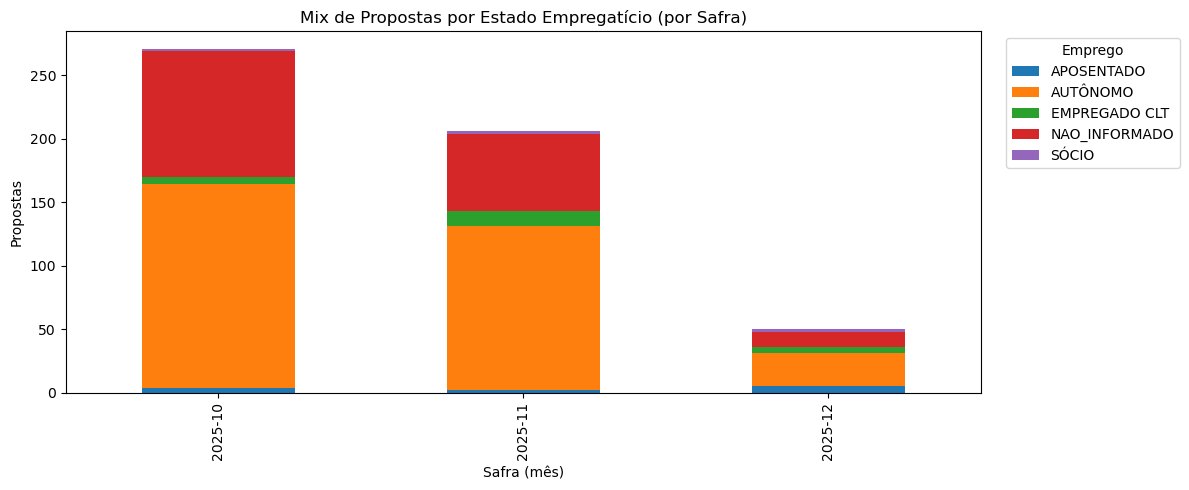

In [99]:
pivot = emp_top.pivot_table(
    index="Safras_Mes",
    columns="Estado Empregatício Informado",
    values="propostas",
    aggfunc="sum",
    fill_value=0
).sort_index()

ax = pivot.plot(kind="bar", stacked=True, figsize=(12,5))
ax.set_title("Mix de Propostas por Estado Empregatício (por Safra)")
ax.set_xlabel("Safra (mês)")
ax.set_ylabel("Propostas")
ax.legend(title="Emprego", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

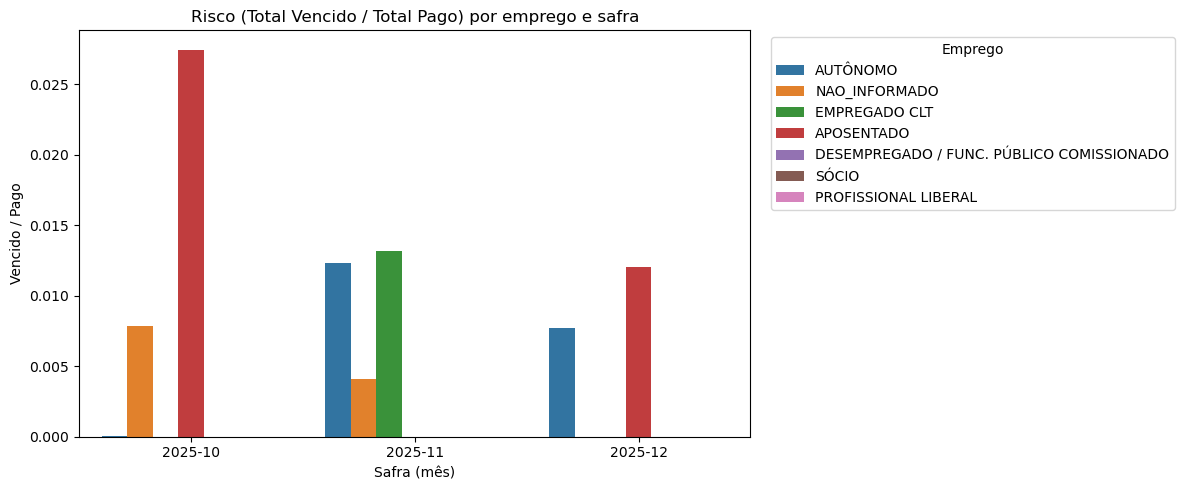

In [101]:
emp_df2 = kpi_emprego.copy()
emp_df2["vencido_ratio"] = emp_df2["total_vencido"] / emp_df2["total_pago"]

plt.figure(figsize=(12,5))
sns.barplot(
    data=emp_df2.sort_values("Safras_Mes"),
    x="Safras_Mes",
    y="vencido_ratio",
    hue="Estado Empregatício Informado"
)
plt.title("Risco (Total Vencido / Total Pago) por emprego e safra")
plt.xlabel("Safra (mês)")
plt.ylabel("Vencido / Pago")
plt.legend(title="Emprego", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [103]:
d = df_safras.copy()
d.columns = [c.strip() for c in d.columns]

# --- helpers ---
def to_bool_sim_nao(s):
    s = s.astype("string").str.strip().str.lower()
    return s.isin(["sim", "s", "true", "1", "yes"])

def to_float_br(s):
    s = s.astype("string").str.strip()
    s = s.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
    s = s.str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
    return pd.to_numeric(s, errors="coerce")

# --- datas essenciais ---
for c in ["Creation Date", "Data Analise/Proposta", "dataVencimento 1a Parcela"]:
    if c in d.columns:
        d[c] = pd.to_datetime(d[c], errors="coerce")

# Safra (originação): Creation Date com fallback para Data Analise/Proposta
base_dt = d["Creation Date"].fillna(d["Data Analise/Proposta"])
d["Safras_Mes"] = base_dt.dt.to_period("M").astype(str)

# Contrato (pago/emprestado)
d["contrato_flag"] = d["[PAGO] Valor Emprestado"].fillna(0) > 0
d["Valor_Pago"] = np.where(d["contrato_flag"], d["[PAGO] Valor Emprestado"].fillna(0), 0)

# Clínica (garante string)
d["Clinica"] = d["Clinica"].astype("string").fillna("SEM_CLINICA")

In [105]:
for c in ["Consulta scr erro?", "consulta srm filme erro?", "Realizar Ligação WC?",
          "[PH3A] Tem telefone HOT?", "[PH3A] Telefone HOT é o da Proposta?"]:
    if c in d.columns:
        d[c] = to_bool_sim_nao(d[c])

d["inc_erro_consulta"] = d["Consulta scr erro?"] | d["consulta srm filme erro?"]
d["inc_wc"] = d["Realizar Ligação WC?"]

# HOT: trate separado (mais “sinal de risco/fraude” do que incidente operacional)
d["inc_tel_hot"] = d["[PH3A] Tem telefone HOT?"]
d["inc_hot_nao_bate"] = d["[PH3A] Tem telefone HOT?"] & (~d["[PH3A] Telefone HOT é o da Proposta?"])

# Operacional core
d["inc_operacional_core"] = d["inc_erro_consulta"] | d["inc_wc"]

In [107]:
pay_id_cols = [f"DT|Payment {i}" for i in range(1, 7)]
for i, c in enumerate(pay_id_cols, start=1):
    s = d[c].astype("string").str.strip()
    d[f"paid_p{i}"] = s.notna() & (s != "") & (s != "0") & (s.str.lower() != "nan")

In [109]:
AS_OF = pd.Timestamp.today().normalize()  # ou pd.Timestamp("2025-12-31")

due1 = "dataVencimento 1a Parcela"
d[due1] = pd.to_datetime(d[due1], errors="coerce")

# vencimentos mensais: p1 = due1, p2 = +1 mês, ..., p6 = +5 meses
due_dates = {i: d[due1] + pd.DateOffset(months=i-1) for i in range(1, 7)}

dpd_cols = []
for i in range(1, 7):
    due = due_dates[i]
    paid = d[f"paid_p{i}"]

    dpd_i = np.where(paid, 0, (AS_OF - due).dt.days)
    dpd_i = pd.Series(dpd_i, index=d.index).clip(lower=0)  # ainda não venceu => 0

    d[f"dpd_p{i}"] = dpd_i
    dpd_cols.append(f"dpd_p{i}")

d["dpd_max_atual"] = d[dpd_cols].max(axis=1)

# flags DPD
d["dpd30"] = d["dpd_max_atual"] >= 30
d["dpd60"] = d["dpd_max_atual"] >= 60
d["dpd90"] = d["dpd_max_atual"] >= 90

# elegibilidade (não punir contrato recente)
d["elig30"] = d[due1].notna() & (d[due1] <= AS_OF - pd.Timedelta(days=30))
d["elig60"] = d[due1].notna() & (d[due1] <= AS_OF - pd.Timedelta(days=60))
d["elig90"] = d[due1].notna() & (d[due1] <= AS_OF - pd.Timedelta(days=90))

# indicadores elegíveis (para somar corretamente)
d["dpd30_elig"] = d["dpd30"] & d["elig30"]
d["dpd60_elig"] = d["dpd60"] & d["elig60"]
d["dpd90_elig"] = d["dpd90"] & d["elig90"]

In [111]:
# garante float nos dois lados
scr1 = to_float_br(d["SCR - Total Vencido"]).astype("float64")
scr2 = to_float_br(d["Filme SCR - Total Vencido"]).astype("float64") if "Filme SCR - Total Vencido" in d.columns else None

# escolhe SCR - Total Vencido; se faltar, usa Filme SCR - Total Vencido
d["scr_total_vencido"] = scr1
if scr2 is not None:
    d["scr_total_vencido"] = d["scr_total_vencido"].combine_first(scr2)


In [115]:
min_contratos = 30  # ajuste se Dezembro tiver pouco volume

base = d[d["contrato_flag"]].copy()

clin_kpi = (base.groupby(["Safras_Mes","Clinica"], as_index=False)
    .agg(
        contratos=("unique id","count"),
        total_pago=("Valor_Pago","sum"),

        # A) DPD por contrato (entre elegíveis)
        elig30=("elig30","sum"),
        dpd30_elig=("dpd30_elig","sum"),
        elig60=("elig60","sum"),
        dpd60_elig=("dpd60_elig","sum"),
        elig90=("elig90","sum"),
        dpd90_elig=("dpd90_elig","sum"),

        # B) operacional
        tx_wc=("inc_wc","mean"),
        tx_erro_consulta=("inc_erro_consulta","mean"),
        tx_operacional=("inc_operacional_core","mean"),
        tx_tel_hot=("inc_tel_hot","mean"),
        tx_hot_nao_bate=("inc_hot_nao_bate","mean"),

        # Proxy R$ externo (SCR)
        scr_vencido_total=("scr_total_vencido","sum"),
        scr_vencido_medio=("scr_total_vencido","mean"),
    )
)

# taxas finais (evita divisão por zero)
clin_kpi["tx_dpd30"] = clin_kpi["dpd30_elig"] / clin_kpi["elig30"].replace({0: np.nan})
clin_kpi["tx_dpd60"] = clin_kpi["dpd60_elig"] / clin_kpi["elig60"].replace({0: np.nan})
clin_kpi["tx_dpd90"] = clin_kpi["dpd90_elig"] / clin_kpi["elig90"].replace({0: np.nan})

# normalização SCR (pra comparar clínicas com volumes diferentes)
clin_kpi["scr_vencido_sobre_pago"] = clin_kpi["scr_vencido_total"] / clin_kpi["total_pago"].replace({0: np.nan})

# filtra volume mínimo
clin_kpi_f = clin_kpi[clin_kpi["contratos"] >= min_contratos].copy()


In [147]:
clin_kpi_f

,Safras_Mes,Clinica,contratos,total_pago,elig30,dpd30_elig,elig60,dpd60_elig,elig90,dpd90_elig,tx_wc,tx_erro_consulta,tx_operacional,tx_tel_hot,tx_hot_nao_bate,scr_vencido_total,scr_vencido_medio,tx_dpd30,tx_dpd60,tx_dpd90,scr_vencido_sobre_pago
20,2025-12,PM10696 - DENTALIS ORTOVITAL MATRIZ,34,90791.100,34,3,34,2,34,2,0.000000,0.058824,0.058824,0.264706,0.205882,0.00,0.000000,0.088235,0.058824,0.058824,0.000000
32,2025-12,PM10895 - CORREIA ODONTOLOGIA,187,705517.760,184,16,182,16,182,16,0.026738,0.026738,0.026738,0.502674,0.213904,1566599.81,8377.539091,0.086957,0.087912,0.087912,2.220497
49,2025-12,PM11210 - CLINICA ODONTOLOGICA VIVA SORRINDO I...,32,74775.100,32,5,32,5,32,5,0.000000,0.000000,0.000000,0.437500,0.312500,560874.00,17527.312500,0.156250,0.156250,0.156250,7.500812
70,2025-12,PM11352 - CORREIA ODONTOLOGIA ANDRADINA,107,400647.210,96,10,94,10,93,10,0.112150,0.065421,0.140187,0.570093,0.242991,1289326.00,12163.452830,0.104167,0.106383,0.107527,3.218108
86,2025-12,PM11600 - ULTRA FACIL ODONTOLOGIA,59,148079.470,59,11,59,11,59,11,0.000000,0.000000,0.000000,0.406780,0.305085,529629.56,8976.772203,0.186441,0.186441,0.186441,3.576658
90,2025-12,PM11608 - CORREIA ODONTOLOGIA JALES,37,124669.147,36,1,34,1,31,0,0.135135,0.081081,0.135135,0.324324,0.108108,38092.00,1029.513514,0.027778,0.029412,0.000000,0.305545
95,2025-12,PM11713 - SORRISO DO POVO SAO LOURENCO,52,107921.000,52,9,52,9,52,9,0.000000,0.000000,0.000000,0.519231,0.365385,1020702.00,19628.884615,0.173077,0.173077,0.173077,9.457863
97,2025-12,PM11716 - SORRISO DO POVO PARAISOPOLIS,75,160545.370,75,18,75,18,75,18,0.000000,0.000000,0.000000,0.493333,0.306667,392063.52,5227.513600,0.240000,0.240000,0.240000,2.442073
99,2025-12,PM11732 - QSORRISO QSORRISO ARARAS,82,166964.400,82,5,82,5,82,5,0.000000,0.060976,0.060976,0.597561,0.304878,71610.40,930.005195,0.060976,0.060976,0.060976,0.428896
102,2025-12,PM11738 - {ODONTO COMPANY} ITUMBIARA,46,115877.000,46,1,46,1,46,1,0.000000,0.000000,0.000000,0.500000,0.173913,90131.00,1959.369565,0.021739,0.021739,0.021739,0.777816
